## RB visualizer DEF

/home/me/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


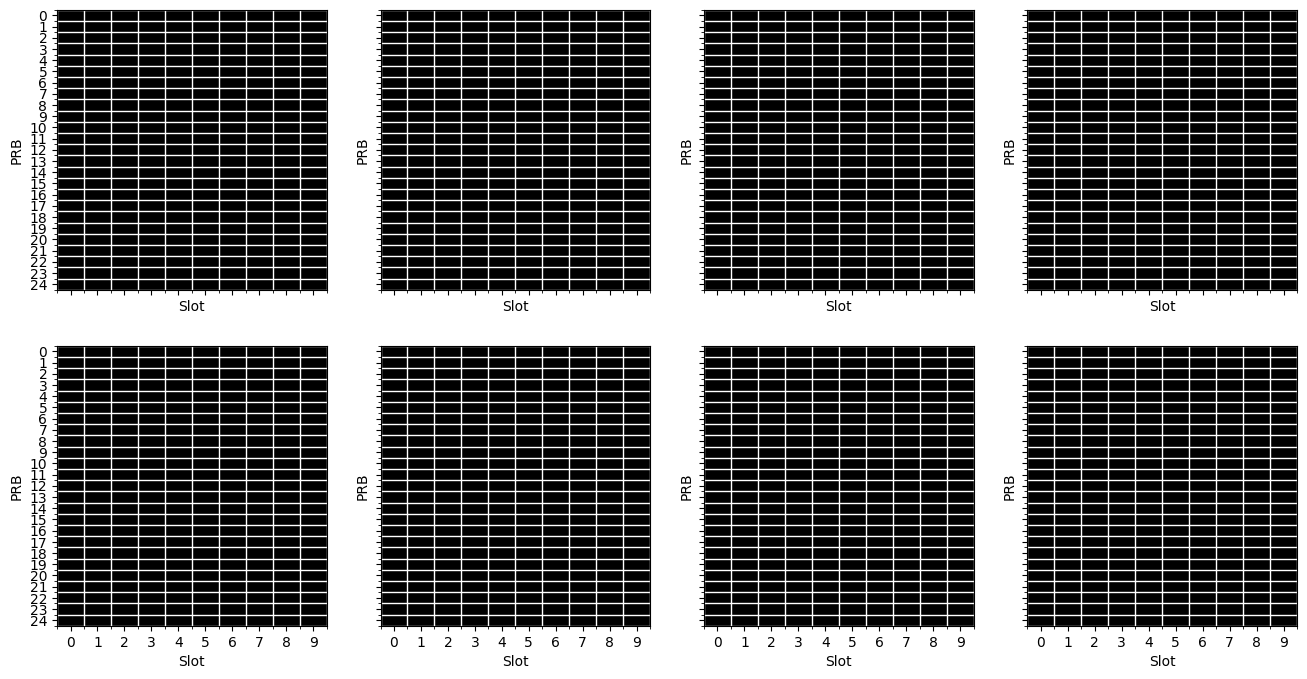

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from IPython.display import clear_output, display


# —— COLOR MAPPING —— 
label_to_int = {"business":0, "performance":1, "critical":2}
colors      = ["green","cyan","red","black"]   # last = “none”
cmap        = ListedColormap(colors)
T= 10
K=25
def alloc_df_to_grid(df):
    """Turn allocation_df with columns ['Slot','PRB','Slice'] into a 10×25 DataFrame of labels."""
    grid = np.full((T, K), np.nan, dtype=object)
    for _, r in df.iterrows():
        # r.Slice ∈ {1,2,3} → map 1→"critical", 2→"performance", 3→"business"
        lbl = {1:"critical", 2:"performance", 3:"business"}.get(r.Slice, np.nan)
        grid[int(r.Slot), int(r.PRB)] = lbl
    return pd.DataFrame(grid, index=range(T), columns=range(K))

# —— SETUP FIGURE ONCE (8 methods) —— 
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharex=True, sharey=True)
axes = axes.flatten()
images = []
for ax in axes:
    # start all black
    init = np.full((K, T), 3, dtype=int)
    im = ax.imshow(init, aspect="auto", cmap=cmap, vmin=0, vmax=3)
    ax.set_xticks(np.arange(T))
    ax.set_yticks(np.arange(K))
    ax.set_xlabel("Slot")
    ax.set_ylabel("PRB")
    ax.grid(which="minor", color="w", linewidth=1)
    ax.set_xticks(np.arange(-.5, T, 1), minor=True)
    ax.set_yticks(np.arange(-.5, K, 1), minor=True)
    images.append(im)



## GRID

In [2]:
from IPython.display import display, clear_output
from ipywidgets import Output

# Create one Output widget for grids:
grid_out = Output()
display(grid_out)


# this is to remeove the cell outptut warning

import warnings

# Hide all FutureWarnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Or more narrowly, only suppress that specific replace‐downcasting message:
warnings.filterwarnings(
    "ignore",
    message=".*Downcasting behavior in `replace` is deprecated.*"
)

Output()

# Main

2026-03-04 13:44:20.653209: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-04 13:44:20.653236: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-04 13:44:20.654177: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-04 13:44:20.659757: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-04 13:44:21.613201: W tensorflow/compiler/tf2

[Ep  1] Thr=94256.0, PRB=56.4%, Viol=6, Reward=-52825.79
[Ep  2] Thr=92391.0, PRB=59.6%, Viol=5, Reward=-48892.24
[Ep  3] Thr=79072.3, PRB=56.4%, Viol=11, Reward=-52954.12
[Ep  4] Thr=96278.1, PRB=60.4%, Viol=7, Reward=-47920.78
[Ep  5] Thr=81122.1, PRB=54.8%, Viol=9, Reward=-54850.48
[Ep  6] Thr=82810.5, PRB=48.0%, Viol=10, Reward=-63465.40
[Ep  7] Thr=92101.2, PRB=54.8%, Viol=9, Reward=-54911.35
[Ep  8] Thr=78045.7, PRB=50.8%, Viol=8, Reward=-60051.47
[Ep  9] Thr=97864.6, PRB=80.0%, Viol=13, Reward=-23453.94
[Ep 10] Thr=78020.9, PRB=54.4%, Viol=9, Reward=-55524.48
[Ep 11] Thr=85658.9, PRB=53.2%, Viol=13, Reward=-57021.92
[Ep 12] Thr=98456.6, PRB=62.4%, Viol=8, Reward=-45398.69
[Ep 13] Thr=104977.1, PRB=67.6%, Viol=6, Reward=-38923.96
[Ep 14] Thr=76146.6, PRB=55.6%, Viol=9, Reward=-53966.07
[Ep 15] Thr=104740.4, PRB=73.2%, Viol=6, Reward=-31890.98
[Ep 16] Thr=98386.9, PRB=59.6%, Viol=7, Reward=-48926.99
[Ep 17] Thr=100775.1, PRB=64.4%, Viol=6, Reward=-42848.32
[Ep 18] Thr=100920.1, PR

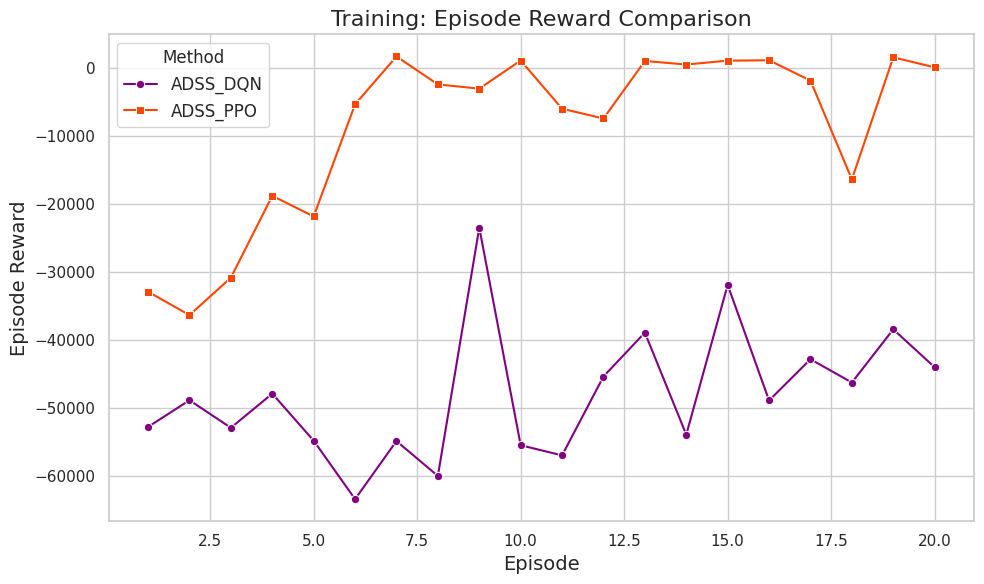

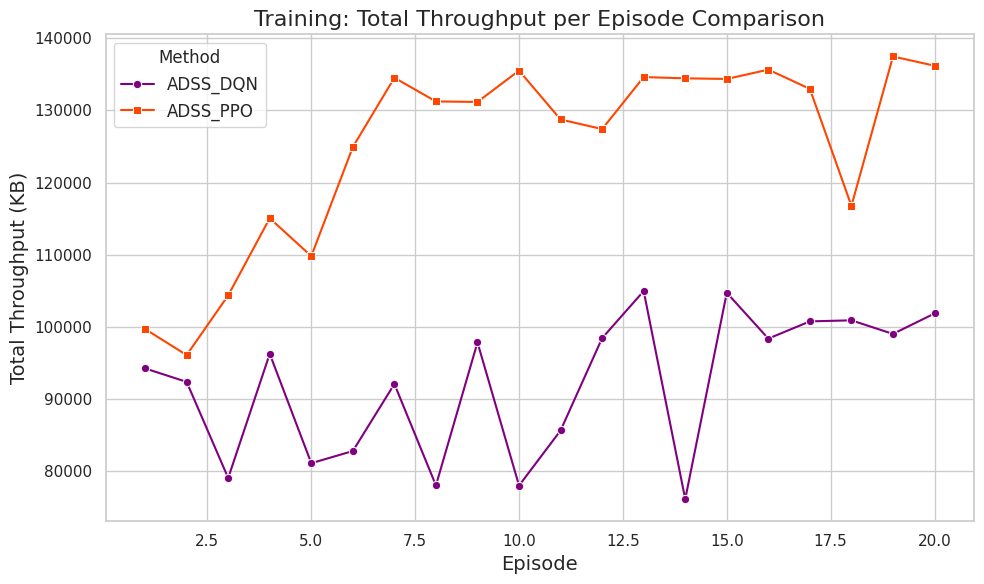

Loaded trained DQN network for inference!
Loaded trained PPO network for inference!


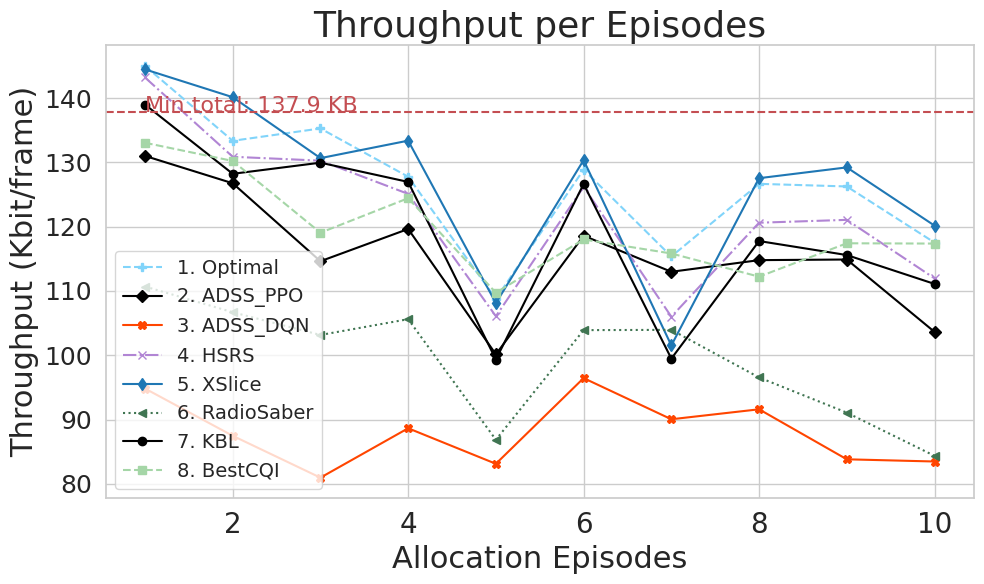

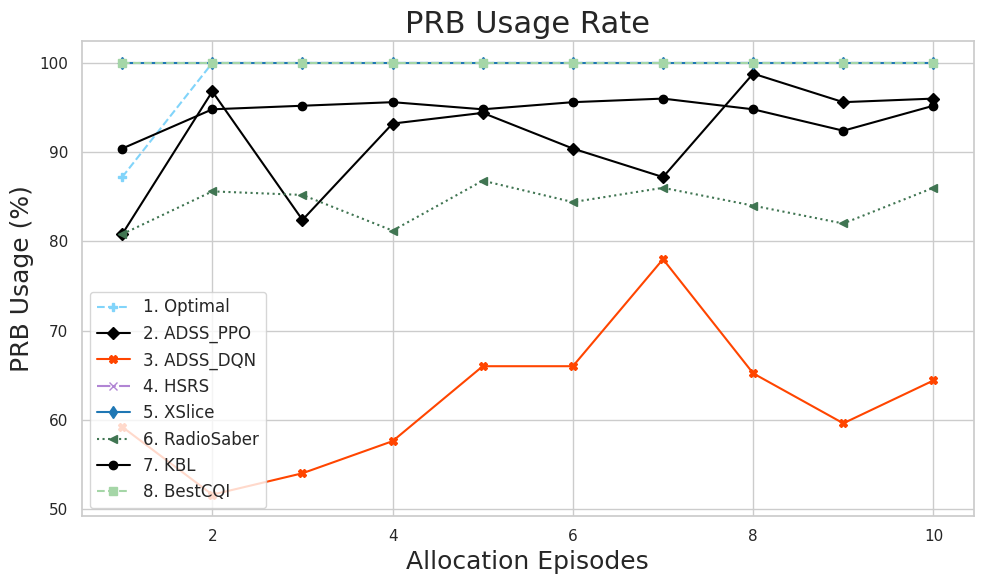

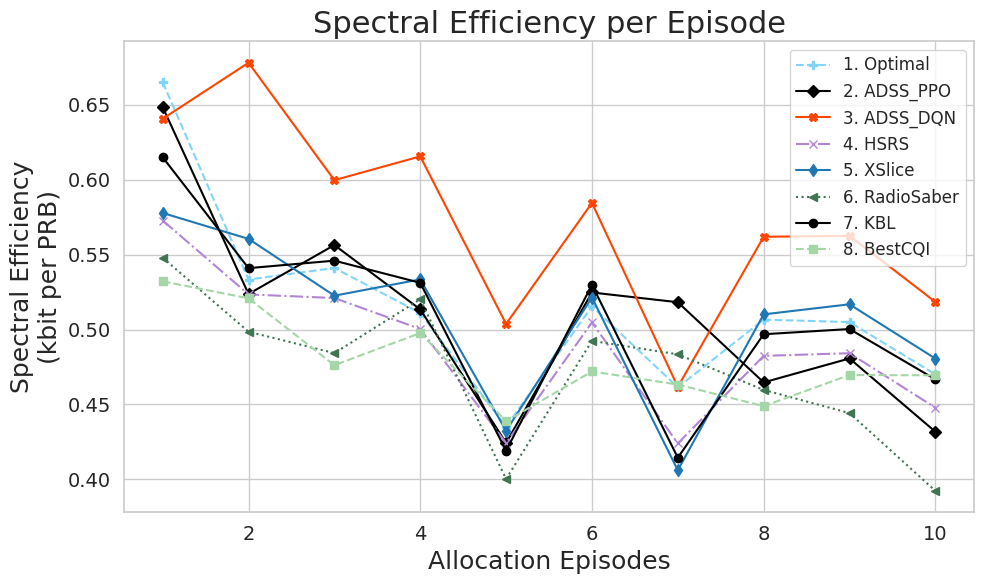

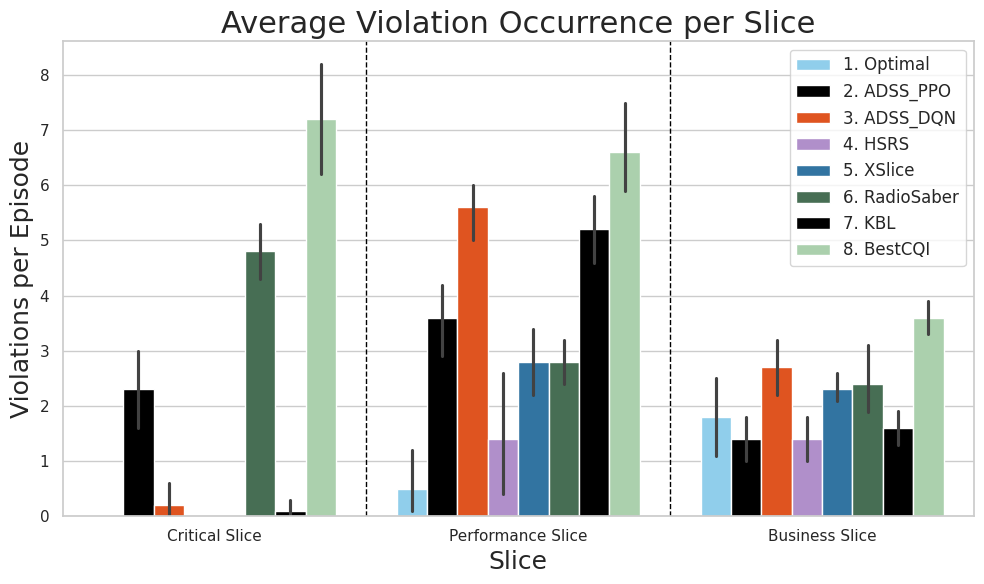

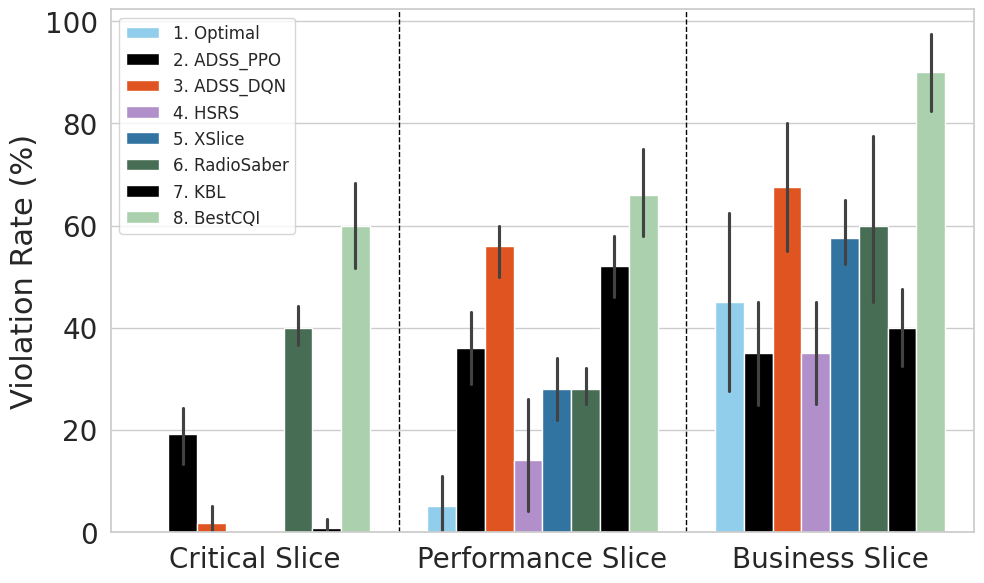

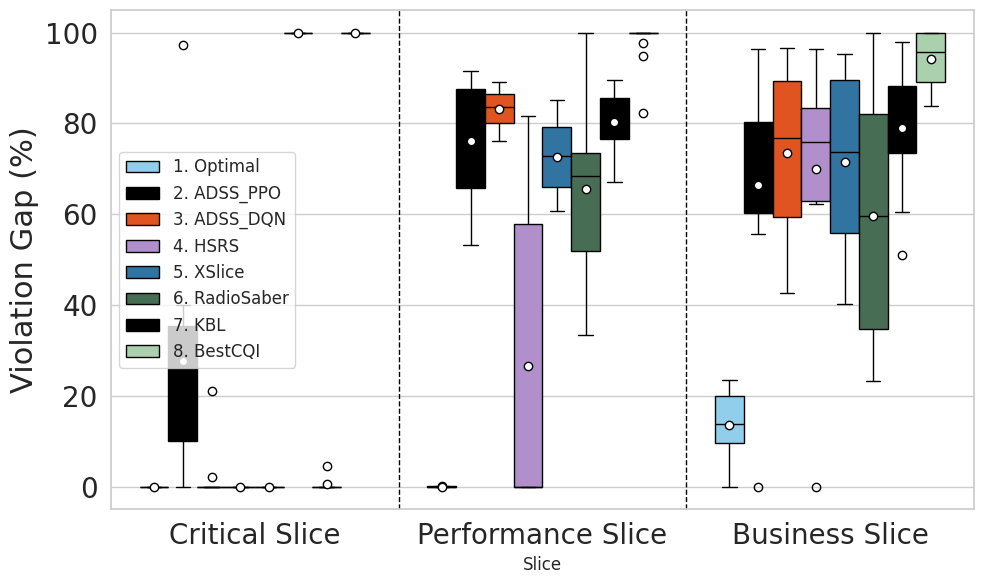

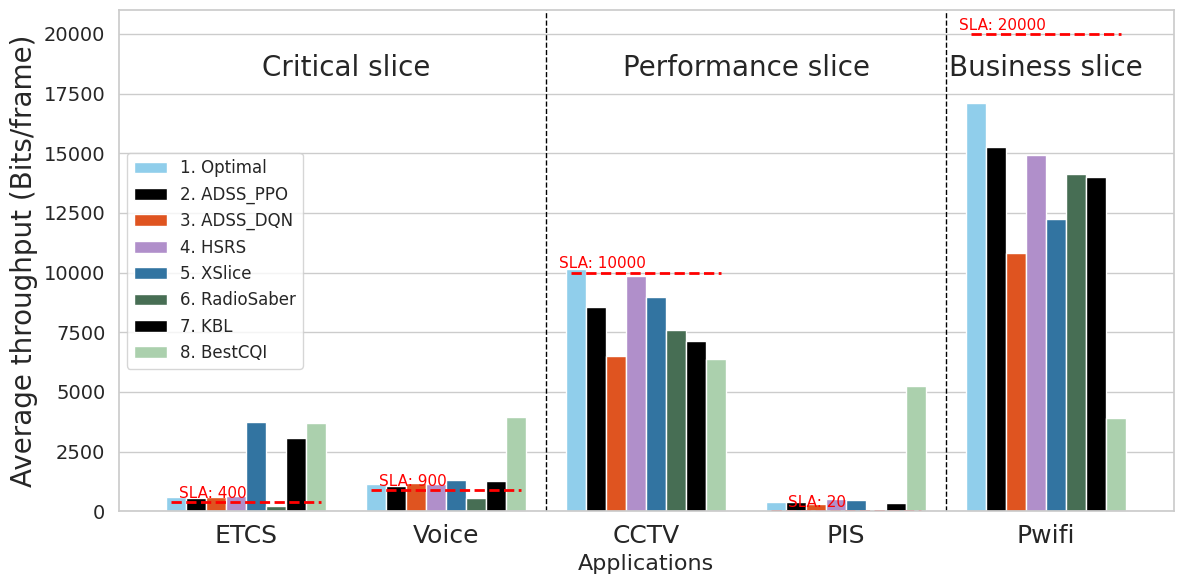

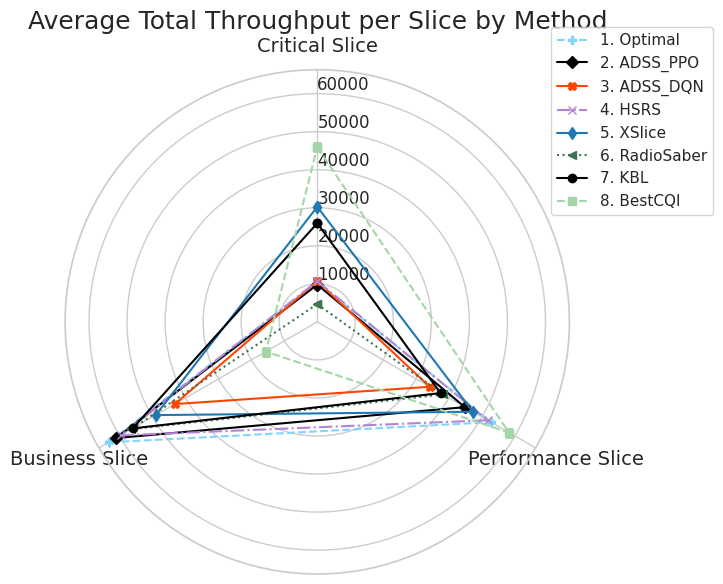

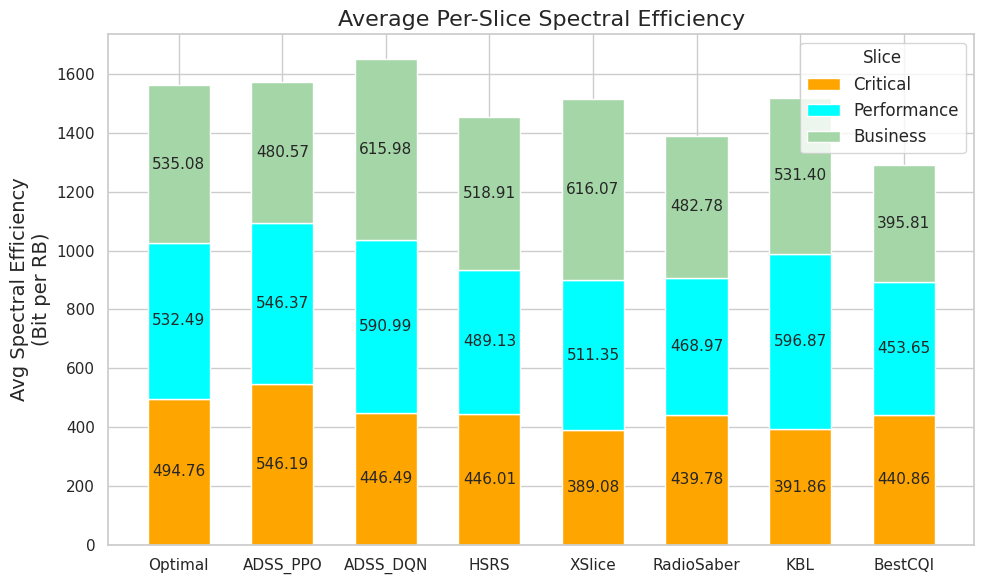

In [3]:
import random
import numpy as np
import pandas as pd
import time 
from gurobipy import Model, GRB, quicksum
import math
from stable_baselines3.common.noise import NormalActionNoise
import matplotlib.pyplot as plt
import seaborn as sns

from typing import Optional
import gym
from gym import spaces
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

import os
from functools import lru_cache
from collections import defaultdict

%load_ext autoreload
%autoreload 2

from ourfunctions import (
    generate_gamma,
    run_myheuristic_allocation,
    run_allocation_solver,
    run_bestcqi_allocation,
    run_radiosaber_allocation,
    run_kbl_allocation,
    run_xslice_allocation,
    plot_all_results, print_final_results,
    get_sla, get_num_users_for_slice, get_slice_for_app,
    slice_spectral_efficiency, prbs_used_per_slice,plot_training_metrics, plot_all_results, plot_compare_training,
    APPKEY_LIST,
    K, T,
    min_required_datarate_KB
)
num_simulations = 10
TRAIN_XSLICE = True

hidden_size=128
n_steps=250
agent_gamma = 0.99
lam=0.25
clip_range=0.2
lr=0.005
batch_size=64
n_epochs=8
alpha=0.8
lambda_weight=0.5
weights = {1:120, 2:8, 3:2}
entropy_coef=0.02 
value_coef = 0.5
partial_train_steps= 2000
train_episode= 20
violation_threshold = 4
usage_threshold = 90

ACTION_NONE, ACTION_CRITIC, ACTION_PERF, ACTION_BUSI = 0, 1, 2, 3
N_ACTIONS = 4
OBS_DIM = 8
frames = []
#print(f"the minimum required {min_required_datarate_KB}")


class MultiSliceAllocationEnv(gym.Env):
    def __init__(self, input_gamma=None):
        super().__init__()
        self.input_gamma = input_gamma
        self.action_space = gym.spaces.Discrete(N_ACTIONS)
        self.observation_space = gym.spaces.Box(
            low=0.0, high=1e9, shape=(OBS_DIM,), dtype=np.float32
        )
        self.T = T
        self.K = K
        self.current_t = 0
        self.current_prb = 0
        self.slot_winners = set()
        self.gamma_critic = 0.0
        self.gamma_perf   = 0.0
        self.gamma_busi   = 0.0
        self.best_critic_delta   = 0.0
        self.gamma = {}
        self.allocation_so_far = {ak:0.0 for ak in APPKEY_LIST}
        self.mask_appkey = {ak:1 for ak in APPKEY_LIST}
        self.allocation_records = []
        self.best_critic_appkey = None
        self.best_perf_appkey   = None
        self.best_busi_appkey   = None
        self.best_critic_delta_appkey   = None
        self.reset()

    def reset(self):
        self.current_t = 0
        self.current_prb = 0
        self.gamma = self.input_gamma if self.input_gamma is not None else generate_gamma()

        # NEW: build a dict prb → list of (appk, thr)
        self.gamma_by_prb = defaultdict(list)
        for (u, a, s, p), thr in self.gamma.items():
            appk = (u, a, s)
            self.gamma_by_prb[p].append((appk, thr))

        # reset allocations, masks, records…
        for ak in APPKEY_LIST:
            self.allocation_so_far[ak] = 0.0
            self.mask_appkey[ak] = 1
        self.allocation_records.clear()
        return self._get_observation()
    def step(self, action):
        prb_idx = self.current_prb

        # 1) pick the pre-computed best app for this PRB & slice
        choice_app = [
            None,
            self.best_critic_appkey,
            self.best_perf_appkey,
            self.best_busi_appkey
        ][int(action)]

        reward = 0.0

          # 3) allocate throughput for only the selected app
        if choice_app is not None:
            thr = self.gamma.get((choice_app[0], choice_app[1], choice_app[2], prb_idx), 0.0)
            self.allocation_so_far[choice_app] += thr
            self.allocation_records.append(
                (self.current_t, prb_idx,
                choice_app[0], choice_app[1], choice_app[2],
                thr)
            )
           
            # 4) compute reward just for that single app
            
            sla = get_sla(choice_app[1])
            alloc = self.allocation_so_far[choice_app]
            if sla > 0:
                ratio = alloc / sla
                if ratio >= 1.0:
                    # mark SLA met
                    self.mask_appkey[choice_app] = 0
                reward += (thr / 1070.055) * weights[choice_app[2]]

            
        
        else:
            
          # 2) If agent chose NONE but there is still demand → penalize heavily
            

            unmet_prb = False
            for appk in (self.best_critic_appkey, self.best_perf_appkey, self.best_busi_appkey):
                if appk is not None and self.mask_appkey.get(appk, 0) == 1:
                    unmet_prb = True
                    break
            if unmet_prb:
                reward -= 500.0

        # 5) advance PRB / slot pointers
        self.current_prb += 1
        if self.current_prb >= self.K:
            self.current_prb = 0
            self.current_t  += 1
            

        done = (self.current_t >= self.T)
        obs  = self._get_observation()
        return obs, reward, done, {}

    def _update_best_slices(self):
        prb = self.current_prb
        entries = self.gamma_by_prb.get(prb, [])  # a tiny list

        # Precompute slack for critical apps once
        slack = {
            appk: max(0.0, get_sla(appk[1]) - self.allocation_so_far[appk])
            for appk in APPKEY_LIST if appk[2] == 1
        }
        self.best_critic_delta = 0.0
        self.gamma_critic = self.gamma_perf = self.gamma_busi = 0.0
        self.best_critic_appkey = self.best_perf_appkey = self.best_busi_appkey = None

        # Scan only the relevant entries for this PRB
        for appk, thr in entries:
            if self.mask_appkey.get(appk, 0) == 0:
                continue

            slice_id = appk[2]
            if slice_id == 1:
                need = slack.get(appk, 0.0)
                if need <= 0.0:
                    continue
                delta = min(need, thr)
                if delta > self.best_critic_delta:
                    self.best_critic_delta = delta
                    self.gamma_critic = thr
                    self.best_critic_appkey = appk

            elif slice_id == 2:
                if thr > self.gamma_perf:
                    self.gamma_perf = thr
                    self.best_perf_appkey = appk

            else:  # slice_id == 3
                if thr > self.gamma_busi:
                    self.gamma_busi = thr
                    self.best_busi_appkey = appk


    def _get_observation(self):
        self._update_best_slices()
        k = self.current_prb

        def filled_ratio(appk):
            if appk is None:
                return 1.0            # treat “no candidate” as fully fulfilled
            sla = get_sla(appk[1])
            alloc = self.allocation_so_far[appk]
            return min(alloc / sla, 1.0)

        fr_c = filled_ratio(self.best_critic_appkey)
        fr_p = filled_ratio(self.best_perf_appkey)
        fr_b = filled_ratio(self.best_busi_appkey)

        # compute γ_x as before (0 when appk is None)
        g_c = (self.gamma_critic / 1070.055) if self.best_critic_appkey else 0.0
        g_p = (self.gamma_perf   / 1070.055) if self.best_perf_appkey   else 0.0
        g_b = (self.gamma_busi   / 1070.055) if self.best_busi_appkey   else 0.0

        return np.array([
            float(self.current_t),
            float(k) / (self.K - 1),
            g_c, g_p, g_b,
            fr_c, fr_p, fr_b
        ], dtype=np.float32)


class RolloutBuffer:
    def __init__(self, buffer_size, obs_dim):
        self.buffer_size = buffer_size
        self.obs_dim = obs_dim
        self.observations = np.zeros((buffer_size, obs_dim), dtype=np.float32)
        # keep actions as a single int per step:
        self.actions      = np.zeros(buffer_size,         dtype=np.int32)
        self.rewards      = np.zeros(buffer_size,         dtype=np.float32)
        self.values       = np.zeros(buffer_size,         dtype=np.float32)
        self.dones        = np.zeros(buffer_size,         dtype=bool)
        self.logprobs     = np.zeros(buffer_size,         dtype=np.float32)
        self.advantages   = np.zeros(buffer_size,         dtype=np.float32)
        self.returns      = np.zeros(buffer_size,         dtype=np.float32)
        self.ptr = 0
        self.path_start_idx = 0

    def store(self, obs, action, reward, value, logprob, done):
        idx = self.ptr
        self.observations[idx] = obs
        self.actions[idx]      = action
        self.rewards[idx]      = reward
        self.values[idx]       = value
        self.logprobs[idx]     = logprob
        self.dones[idx]        = done
        self.ptr += 1

    def finish_path(self, last_value, gamma=0.99, lam=0.95):
        path_end = self.ptr
        adv = 0.0
        # compute GAE backwards
        for i in reversed(range(self.path_start_idx, path_end)):
            next_val = 0.0 if self.dones[i] else (
                last_value if i == path_end - 1 else self.values[i+1]
            )
            delta = self.rewards[i] + gamma * next_val - self.values[i]
            adv    = delta + gamma * lam * (0 if self.dones[i] else adv)
            self.advantages[i] = adv
        # compute returns
        for i in range(self.path_start_idx, path_end):
            self.returns[i] = self.values[i] + self.advantages[i]
        self.path_start_idx = self.ptr

    def get(self, batch_size, shuffle=True):
        idxs = np.arange(self.ptr)
        if shuffle:
            np.random.shuffle(idxs)
        for start in range(0, self.ptr, batch_size):
            end = start + batch_size
            batch = idxs[start:end]
            yield (
                self.observations[batch],
                self.actions[batch],      # now shape (batch_size,)
                self.advantages[batch],
                self.returns[batch],
                self.logprobs[batch]
            )

    def reset(self):
        self.ptr = 0
        self.path_start_idx = 0

class ActorNet(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden_size=128):
        super().__init__()
        self.policy = nn.Sequential(
            nn.Linear(obs_dim, hidden_size),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_size, n_actions)
        )

    def forward(self, x):
        return self.policy(x)

class CriticNet(nn.Module):
    def __init__(self, obs_dim, hidden_size=128):
        super().__init__()
        self.value = nn.Sequential(
            nn.Linear(obs_dim, hidden_size),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, x):
        return self.value(x).squeeze(-1)

# =====================================
#  PPO
# =====================================
class PPOAgent:
    def __init__(
        self,
        env,
        obs_dim,
        n_actions,
        lr=3e-4,
        gamma=0.99,
        lam=0.95,
        clip_eps=0.2,
        epochs=4,
        batch_size=64,
        hidden_size=128,
        entropy_coef=0.02,
        value_coef=0.5,
    ):
        self.env = env
        self.gamma = gamma
        self.lam   = lam
        self.clip_eps     = clip_eps
        self.ppo_epochs   = epochs
        self.batch_size   = batch_size
        self.entropy_coef = entropy_coef
        self.value_coef   = value_coef

        # separate networks
        self.actor = ActorNet(obs_dim, n_actions, hidden_size)
        self.critic = CriticNet(obs_dim, hidden_size)
        self.optimizer = optim.Adam(
            list(self.actor.parameters()) + list(self.critic.parameters()), lr=lr
        )

    def select_action(self, obs_np):
        obs = torch.from_numpy(obs_np).float().unsqueeze(0)
        logits = self.actor(obs)
        dist = Categorical(logits=logits)
        action = dist.sample()
        return (
            action.item(),
            dist.log_prob(action).item(),
            self.critic(obs).item()
        )

    def update(self, buffer):
        for _ in range(self.ppo_epochs):
            for (obs_b, act_b, adv_b, ret_b, logp_b) in buffer.get(self.batch_size):
                obs_t = torch.from_numpy(obs_b)
                act_t = torch.from_numpy(act_b)
                adv_t = torch.from_numpy(adv_b)
                ret_t = torch.from_numpy(ret_b)
                old_logp_t = torch.from_numpy(logp_b)

                # actor forward
                logits = self.actor(obs_t)
                dist = Categorical(logits=logits)
                logp = dist.log_prob(act_t)
                entropy = dist.entropy().mean()

                # critic forward
                value = self.critic(obs_t)

                # surrogate policy loss
                ratio = torch.exp(logp - old_logp_t)
                clipped = torch.clamp(ratio, 1 - self.clip_eps, 1 + self.clip_eps) * adv_t
                policy_loss = -torch.min(ratio * adv_t, clipped).mean()

                # value loss
                value_loss = nn.functional.mse_loss(value, ret_t)

                # total loss
                loss = policy_loss + self.value_coef * value_loss - self.entropy_coef * entropy

                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()
        buffer.reset()


def train_adss_ppo_agent(gamma, num_episodes, partial_train_steps, violation_threshold, usage_threshold):
    env = MultiSliceAllocationEnv(input_gamma=gamma)
    obs_dim   = env.observation_space.shape[0]
    n_actions = env.action_space.n

    agent = PPOAgent(
        env=env,
        obs_dim=obs_dim,
        n_actions=n_actions,
        lr=lr,
        gamma=agent_gamma,
        lam=lam,
        clip_eps=clip_range,
        epochs=4,
        batch_size=64,
        hidden_size=128,
        entropy_coef=entropy_coef,
        value_coef=value_coef,
    )
    buffer = RolloutBuffer(partial_train_steps, obs_dim)

    episodes, throughputs, prb_usages = [], [], []
    violations, rewards = [], []
    avg_gap_ratios, avg_prb_usages = [], []

    for ep in range(num_episodes):
        obs = env.reset()
        ep_reward = 0.0
        for t in range(partial_train_steps):
            action, logp, value = agent.select_action(obs)
            next_obs, rew, done, _ = env.step(action)
            buffer.store(obs, action, rew, value, logp, done)
            obs = next_obs

            if done:
                last_val = 0.0
                obs = env.reset()
            else:
                with torch.no_grad():
                    last_val = agent.critic(torch.from_numpy(obs).float().unsqueeze(0)).item()

            if done or t == partial_train_steps - 1:
                buffer.finish_path(last_val, gamma=agent.gamma, lam=agent.lam)

        agent.update(buffer)

        # Evaluation
        test_gamma = gamma #generate_gamma(time_idx=ep)
        test_env   = MultiSliceAllocationEnv(input_gamma=test_gamma)
        obs_eval   = test_env.reset()
        done_eval  = False
        eval_reward = 0.0
        while not done_eval:
            action, _, _ = agent.select_action(obs_eval)
            obs_eval, rew_eval, done_eval, _ = test_env.step(action)
            eval_reward += rew_eval

        metrics, _ = compute_adss_allocation_metrics(test_env)
        total_thr  = metrics['Total_Throughput']
        prb_usage  = metrics['PRB_Usage(%)']
        total_viol = metrics['Total_Violations']

        gap_vals = list(metrics.get('Avg_Gap_Ratio_By_App', {}).values())
        prb_vals = list(metrics.get('Avg_PRB_Usage_By_App', {}).values())
        avg_gap_ratio = np.mean(gap_vals) if gap_vals else 0.0
        avg_prb_usage = np.mean(prb_vals) if prb_vals else 0.0

        episodes.append(ep+1)
        throughputs.append(total_thr)
        prb_usages.append(prb_usage)
        violations.append(total_viol)
        rewards.append(eval_reward)
        avg_gap_ratios.append(avg_gap_ratio)
        avg_prb_usages.append(avg_prb_usage)

        print(
            f"[Training Ep {ep+1}] => Thr={total_thr:.2f}KB, PRB_Usage={prb_usage:.1f}%, Viol={total_viol}, Reward={eval_reward:.2f}"
        )
        """
        if total_viol <= violation_threshold and prb_usage >= usage_threshold :
            print(f"Stopping early at episode {ep+1}: violations <= {violation_threshold}, PRB_Usage={prb_usage:.1f}%")
            break
            """
        #if total_viol == 0 and prb_usage == 100 :
        #    print(f"Stopping early at episode {ep+1}: violations <= {violation_threshold}, PRB_Usage={prb_usage:.1f}%")
         #   break

    training_results_df = pd.DataFrame({
        'Episode':             episodes,
        'Total_Throughput_KB': throughputs,
        'PRB_Usage_%':         prb_usages,
        'Total_Violations':    violations,
        'Episode_Reward':      rewards,
        'Avg_Gap_Ratio':       avg_gap_ratios,
        'Avg_PRB_Usage':       avg_prb_usages,
    })

    return agent, env, training_results_df

def train_until_threshold(
    gamma,
    num_episodes,
    partial_train_steps,
    violation_threshold=violation_threshold, usage_threshold=usage_threshold
):
    max_attempts = 50
    attempt = 0
    while attempt < max_attempts:
        attempt += 1
        print(f">>> Training attempt #{attempt}")
        agent, env, training_df = train_adss_ppo_agent(
            gamma=gamma,
            num_episodes=num_episodes,
            partial_train_steps=partial_train_steps,
            violation_threshold=violation_threshold, usage_threshold=usage_threshold
        )
        if len(training_df) < num_episodes:
            print(f"✅ Threshold reached on attempt #{attempt}")
            return agent, env, training_df
        print(f"❌ Threshold NOT reached (ran full {num_episodes} episodes). Retrying...")

    raise RuntimeError(f"Failed to reach threshold in {max_attempts} attempts")

def heuristic_select_action(env, obs, w_perf=0.6, w_busi=0.4):
    """
    Two-phase PRB allocator:
      1) Critical slice: pick ACTION_CRITIC if any unmet slack remains.
      2) Performance vs Business: ACTION_PERF or ACTION_BUSI by weighted throughput.
      3) ACTION_NONE otherwise.
    """
    # Ensure best_*_appkey are up‐to‐date for the current PRB
    env._update_best_slices()
    k = env.current_prb

    # Helper: remaining slack = SLA – allocated
    def slack_for(appk):
        if appk is None:
            return 0.0
        sla   = get_sla(appk[1])
        alloc = env.allocation_so_far[appk]
        return max(0.0, sla - alloc)

    # Phase 1: critical
    crit_app = env.best_critic_appkey
    if crit_app is not None and slack_for(crit_app) > 0:
        return ACTION_CRITIC

    # Phase 2: perf vs busi
    best_score = 0.0
    best_act   = ACTION_NONE

    perf_app = env.best_perf_appkey
    if perf_app is not None and slack_for(perf_app) > 0:
        g = env.gamma.get((*perf_app, k), 0.0)
        score = g * w_perf
        if score > best_score:
            best_score, best_act = score, ACTION_PERF

    busi_app = env.best_busi_appkey
    if busi_app is not None and slack_for(busi_app) > 0:
        g = env.gamma.get((*busi_app, k), 0.0)
        score = g * w_busi
        if score > best_score:
            best_score, best_act = score, ACTION_BUSI

    if best_score > 0.0:
        return best_act

    # No positive candidate
    return ACTION_NONE


# ── Prefill function: run N episodes of the heuristic ──
def prefill_heuristic(agent, gamma, num_episodes=10):
    """
    Runs `num_episodes` of heuristic policy and stores each transition
    into agent's replay buffer before any learning begins.
    """
    demo_env = MultiSliceAllocationEnv(input_gamma=gamma)
    transitions = []
    for _ in range(num_episodes):
        obs = demo_env.reset()
        done = False
        while not done:
            act = heuristic_select_action(demo_env, obs)
            nxt, r, done, _ = demo_env.step(act)
            transitions.append((obs, act, r, nxt, done))
            obs = nxt

    # inject into the agent
    for obs, act, r, nxt, done in transitions:
        agent.store(obs, act, r, nxt, done)

# ------------------------
class TransformerDQNNet(nn.Module):
    def __init__(self, obs_dim, K, d_model=128, n_heads=4, n_layers=3):
        super().__init__()
        hidden=128
        self.mlp=nn.Sequential(
            nn.Linear(obs_dim,hidden), nn.ReLU(inplace=True),
            nn.Linear(hidden,hidden),  nn.ReLU(inplace=True),
            nn.Linear(hidden,N_ACTIONS)
        )
    def forward(self,x):
        q=self.mlp(x)
        batch=x.size(0)
        valid = torch.ones(batch, N_ACTIONS, dtype=torch.bool, device=x.device)
        return q, valid
    
class DQNAgent:
    def __init__(self,
                 env,
                 K,
                 obs_dim,
                 # transformer args—accepted for backward compatibility but unused
                 d_model=None,
                 n_heads=None,
                 n_layers=None,
                 # replay & optimization
                 buffer_size=50_000,
                 batch_size=64,
                 lr=3e-4,
                 gamma=0.99,
                 tau=0.005,
                 # ε-greedy
                 eps_start=1.0,
                 eps_end=0.05,
                 eps_decay=10_000):
        # 1) store env + MDP params
        self.env = env
        self.K   = K
        self.obs_dim = obs_dim

        # 2) build Q-networks (simple MLP)
        self.q_net      = TransformerDQNNet(obs_dim, K)
        self.target_net = TransformerDQNNet(obs_dim, K)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()

        # 3) optimizer & hyperparameters
        self.optim = torch.optim.Adam(self.q_net.parameters(), lr=lr)
        self.gamma = gamma
        self.tau   = tau

        # ε-greedy schedule
        self.eps_start, self.eps_end, self.eps_decay = eps_start, eps_end, eps_decay
        self.total_steps = 0

        # 4) replay buffer
        self.batch_size  = batch_size
        self.mem_obs     = np.zeros((buffer_size, obs_dim), dtype=np.float32)
        self.mem_actions = np.zeros(buffer_size,      dtype=np.int64)
        self.mem_rewards = np.zeros(buffer_size,      dtype=np.float32)
        self.mem_next_obs= np.zeros((buffer_size, obs_dim), dtype=np.float32)
        self.mem_dones   = np.zeros(buffer_size,      dtype=bool)
        self.mem_ptr     = 0
        self.mem_filled  = 0

    def select_action(self, obs_np):
        # ε-greedy
        eps = self.eps_end + (self.eps_start - self.eps_end) * \
              math.exp(-1. * self.total_steps / self.eps_decay)
        self.total_steps += 1
        if np.random.rand() < eps:
            return np.random.randint(0, N_ACTIONS)

        with torch.no_grad():
            q, _ = self.q_net(torch.from_numpy(obs_np).float().unsqueeze(0))
            return int(q.argmax(dim=-1).item())

    def store(self, obs, action, reward, next_obs, done):
        idx = self.mem_ptr % len(self.mem_rewards)
        self.mem_obs[idx]      = obs
        self.mem_actions[idx]  = action
        self.mem_rewards[idx]  = reward
        self.mem_next_obs[idx] = next_obs
        self.mem_dones[idx]    = done
        self.mem_ptr    += 1
        self.mem_filled = min(self.mem_filled + 1, len(self.mem_rewards))

    def update_network(self):
        if self.mem_filled < self.batch_size:
            return
        idxs  = np.random.choice(self.mem_filled, self.batch_size, replace=False)
        obs_b = torch.from_numpy(self.mem_obs[idxs]).float()
        act_b = torch.from_numpy(self.mem_actions[idxs]).long().unsqueeze(-1)
        rew_b = torch.from_numpy(self.mem_rewards[idxs]).float()
        nxt_b = torch.from_numpy(self.mem_next_obs[idxs]).float()
        done_b= torch.from_numpy(self.mem_dones[idxs]).float()

        # Q(s,a)
        q_pred, _  = self.q_net(obs_b)
        q_sa       = q_pred.gather(-1, act_b).squeeze(-1)

        # target: r + γ max_a' Q_target(s',a')
        with torch.no_grad():
            q_next, _  = self.target_net(nxt_b)
            q_max_next = q_next.max(dim=-1).values
            target     = rew_b + self.gamma * (1 - done_b) * q_max_next

        loss = nn.functional.mse_loss(q_sa, target)
        self.optim.zero_grad()
        loss.backward()
        self.optim.step()

    def soft_update_target(self):
        with torch.no_grad():
            for p, pt in zip(self.q_net.parameters(), self.target_net.parameters()):
                pt.data.mul_(1 - self.tau).add_(p.data, alpha=self.tau)

    def learn(self,
              num_steps,
              start_learn=1000,
              update_every=4,
              behavior_fn=None):
        """
        Play `num_steps` PRB‐decisions, store each transition via `store()`,
        and call `update_network()` + `soft_update_target()` every `update_every`
        steps once we've stored at least max(start_learn, batch_size) samples.
        If `behavior_fn` is provided, use it(env, obs)->action; else ε-greedy.
        """
        if behavior_fn is None:
            behavior_fn = lambda e, o: self.select_action(o)

        obs = self.env.reset()
        for step in range(num_steps):
            act = behavior_fn(self.env, obs)
            nxt, r, done, _ = self.env.step(act)
            self.store(obs, act, r, nxt, done)
            obs = nxt if not done else self.env.reset()

            if (self.mem_filled >= start_learn
                    and self.mem_filled >= self.batch_size
                    and step % update_every == 0):
                self.update_network()
                self.soft_update_target()


def train_adss_dqn_agent(gamma,
                     num_episodes,
                     partial_train_steps,
                     w_perf=0.7,
                     w_busi=0.3):
    """
    gamma               : initial γ for episode 0
    num_episodes        : number of episodes to train over
    partial_train_steps : T*K steps per episode (e.g. 250)
    w_perf, w_busi      : weights for perf/busi in heuristic
    """
    # 1) init agent with dummy env
    env   = MultiSliceAllocationEnv(input_gamma=gamma)
    obs_dim = env.observation_space.shape[0]
    agent = DQNAgent(
        env=env,
        K=K,
        obs_dim=obs_dim,
        buffer_size=50_000,
        batch_size=batch_size,
        gamma=agent_gamma,
        lr=lr,
        tau=0.005,
        eps_start=1.0,
        eps_end=0.05,
        eps_decay=10_000,
    )

    # 2) main training loop
    metrics = []
    for ep in range(num_episodes):
        # a) new gamma & reset
        new_gamma = generate_gamma(time_idx=ep)
        agent.env.input_gamma = new_gamma
        agent.env.gamma       = new_gamma
        agent.env.reset()

        # b) learn for T*K steps from the heuristic
        agent.learn(
            num_steps=partial_train_steps,
            start_learn=1000,
            update_every=4,
            behavior_fn=lambda e, o: heuristic_select_action(e, o, w_perf, w_busi)
        )

        # c) evaluate on fresh test env
        test_gamma = generate_gamma(time_idx=ep + num_episodes)
        test_env = MultiSliceAllocationEnv(input_gamma=test_gamma)
        obs = test_env.reset()
        done = False
        total_reward = 0.0
        while not done:
            a = agent.select_action(obs)
            obs, r, done, _ = test_env.step(a)
            total_reward += r

        m, _ = compute_adss_allocation_metrics(test_env)
        metrics.append({
            'Episode':              ep + 1,
            'Total_Throughput_KB':  m['Total_Throughput'],  # renamed for plotting
            'PRB_Usage_%':          m['PRB_Usage(%)'],     # renamed for plotting
            'Total_Violations':     m['Total_Violations'],
            'Episode_Reward':       total_reward
        })
        print(f"[Ep {ep+1:2d}] Thr={m['Total_Throughput']:.1f}, "
              f"PRB={m['PRB_Usage(%)']:.1f}%, Viol={m['Total_Violations']}, "
              f"Reward={total_reward:.2f}")
        """
        if m['Total_Violations'] <= violation_threshold and m['PRB_Usage(%)'] >= usage_threshold :
            print(f"Stopping early at episode {ep+1}: violations <= {m['Total_Violations']}, PRB_Usage={m['PRB_Usage(%)']}%")
            break
            """
    df = pd.DataFrame(metrics)
    return agent, env, df

def compute_adss_allocation_metrics(env):
    columns = ['Slot','PRB','User','App','Slice','Throughput']
    alloc_df = pd.DataFrame(env.allocation_records, columns=columns)
    slice_throughput_df = (
        alloc_df
          .groupby('Slice')['Throughput']
          .sum()
          .reset_index()
          .rename(columns={'Throughput': 'Total_Throughput'})
    )  
    #alloc_df.to_csv("allocation_df_adss_metrics.csv", index= True)
    total_thr = alloc_df['Throughput'].sum()
    avg_thr   = total_thr 
    total_prbs = K * T
    used_prbs  = len(alloc_df)  
    prb_usage_percent = (used_prbs / total_prbs) * 100 if total_prbs > 0 else 0

    # Summarize throughput per (User, App, Slice)
    app_thr_df = (
        alloc_df
        .groupby(['User','App','Slice'])['Throughput']
        .sum()
        .reset_index()
    )

    # -------------
    # 1) Violation & Gap Calculation 
    # -------------
    violation_counts_per_slice = {1: 0, 2: 0, 3: 0}
    violation_gap_per_slice    = {1: 0.0, 2: 0.0, 3: 0.0}
    for (i_, a_, s_) in APPKEY_LIST:
        # Grab how much throughput was allocated to this (user, app, slice)
        row_match = app_thr_df[
            (app_thr_df['User'] == i_) &
            (app_thr_df['App'] == a_) &
            (app_thr_df['Slice'] == s_)
        ]
        sla_needed = get_sla(a_)
        if len(row_match) > 0:
            allocated_thr = row_match.iloc[0]['Throughput']
            ratio = allocated_thr / sla_needed
            if ratio < 1 :
                #gap_ratio = 1-ratio 
                violation_counts_per_slice[s_] += 1
                violation_gap_per_slice[s_] += (1.0 - ratio)
            

        else:
            allocated_thr = 0.0
            
            violation_counts_per_slice[s_] += 1
            violation_gap_per_slice[s_] += 1.0


    # Final step: turn total gap into an average gap for each slice
    for s_ in [1, 2, 3]:
        if violation_counts_per_slice[s_] > 0:
            violation_gap_per_slice[s_] /= violation_counts_per_slice[s_]
        else:
            violation_gap_per_slice[s_] = 0.0

    total_violations = sum(violation_counts_per_slice.values())

    # gap ratio per App
    gap_ratios = {}
    for (i_, a_, s_) in APPKEY_LIST:
        mask = (
            (app_thr_df['User']  == i_) &
            (app_thr_df['App']   == a_) &
            (app_thr_df['Slice'] == s_)
        )
        allocated = app_thr_df.loc[mask, 'Throughput'].sum()
        sla_needed = get_sla(a_)
        ratio = ((sla_needed - allocated) / sla_needed) if sla_needed > 0 else 0.0
        ratio = max(0.0, ratio)
        gap_ratios.setdefault(a_, []).append(ratio)
    avg_gap_ratio_by_app = {app: np.mean(ratios) for app, ratios in gap_ratios.items()}

    # Average number of PRBs used per app
    prb_counts = alloc_df.groupby('App').size().to_dict()  # {app -> #rows}
    avg_prb_usage_by_app = {}
    for app_id, count in prb_counts.items():
        slice_id = get_slice_for_app(app_id)
        n_users = get_num_users_for_slice(slice_id)
        avg_prb_usage_by_app[app_id] = count / float(n_users) if n_users > 0 else 0

    # -------------
    # 3) Final Return
    # -------------
    return {
        'allocation_df': alloc_df,
        'Total_Throughput':       total_thr, 
        'Average_Throughput':     avg_thr,
        'PRB_Usage(%)':           prb_usage_percent,
        'Violation_Counts_Per_Slice': violation_counts_per_slice,
        'Violation_Gap_Per_Slice':    violation_gap_per_slice,
        'Total_Violations':       total_violations,
        'App_Throughput_DF':      app_thr_df,
        'Avg_Gap_Ratio_By_App':   avg_gap_ratio_by_app,
        'Avg_PRB_Usage_By_App':   avg_prb_usage_by_app,
        'Slice_Throughput_df': slice_throughput_df,
    }, app_thr_df


def run_simulation(num_simulations=3, alpha=0.8, lambda_weight=0.7):

    simulation_results = []
    #"""
    gamma_for_training = generate_gamma()  
    #training DQN **********************
    start_time_adss_training = time.time()
    adss_dqn_agent, train_env, training_results_dqn = train_adss_dqn_agent(
        gamma=gamma_for_training,
        num_episodes=train_episode,            
        partial_train_steps=partial_train_steps
    )
    time_taken_adss_training = time.time() - start_time_adss_training

    print(f"[RL Training] => Done training. Time Taken={time_taken_adss_training:.2f}s")
    torch.save(adss_dqn_agent.q_net.state_dict(), "dqn_q_net.pth")
    print("Trained DQN Q-network saved successfully!")
    #"""
    # Training PPO *********************
    #"""
    start_time_adss_training = time.time()
    adss_ppo_agent, train_env, training_results_ppo = train_adss_ppo_agent(
    gamma = gamma_for_training,
    num_episodes       = train_episode,
    partial_train_steps= partial_train_steps,
    violation_threshold= violation_threshold, usage_threshold=usage_threshold)
    time_taken_adss_training = time.time() - start_time_adss_training

    print(f"[RL Training] => Done training. Time Taken={time_taken_adss_training:.2f}s")
    torch.save({
    'actor':  adss_ppo_agent.actor.state_dict(),
    'critic': adss_ppo_agent.critic.state_dict()}, "ppo_adss_checkpoint.pth")
    
    print("Trained PPO policy saved successfully!")

    #"""
    # Plot the training metrics
    plot_compare_training(training_results_dqn,training_results_ppo)
    
    # ── Prepare a fresh DQN agent for inference ─────────────────────────
    dummy_env = MultiSliceAllocationEnv(
        input_gamma=generate_gamma()
    )
    obs_dim = dummy_env.observation_space.shape[0]

    adss_dqn_agent = DQNAgent(
    env=dummy_env,
    K=K,
    obs_dim=obs_dim,

    # model size
    d_model=hidden_size,   # = prb_embed before
    n_heads=4,
    n_layers=3,            # one depth for DQN

    # replay-buffer & SGD
    buffer_size=50_000,    # or n_steps if you like
    batch_size=batch_size,
    lr=lr,

    # RL hyper-params
    gamma=agent_gamma,

    # exploration
    eps_start=1.0,
    eps_end=0.05,
    eps_decay=10_000,)
    # Load the saved policy network weights into the agent's policy network.
  

    adss_dqn_agent.q_net.load_state_dict(torch.load("dqn_q_net.pth"))
    adss_dqn_agent.q_net.eval()
    print("Loaded trained DQN network for inference!")
 

    # ── Prepare a fresh PPO agent for inference ─────────────────────────
    dummy_env = MultiSliceAllocationEnv(input_gamma=generate_gamma())
    obs_dim   = dummy_env.observation_space.shape[0]
    n_actions = dummy_env.action_space.n

    # Create a new PPOAgent with the same hyperparameters
    adss_ppo_agent = PPOAgent(
        env=dummy_env,
        obs_dim=obs_dim,
        n_actions=n_actions,
        lr=3e-3,
        gamma=0.98,
        lam=0.95,
        clip_eps=clip_range,
        epochs=4,
        batch_size=64,
        hidden_size=128,
        entropy_coef=entropy_coef,
        value_coef=value_coef,
    )
  
    ckpt = torch.load("ppo_adss_checkpoint.pth")
    adss_ppo_agent.actor.load_state_dict(ckpt['actor'])
    adss_ppo_agent.critic.load_state_dict(ckpt['critic'])
    adss_ppo_agent.actor.eval()
    adss_ppo_agent.critic.eval()
    print("Loaded trained PPO network for inference!")
  
    
    for sim in range(1, num_simulations + 1):
        #print(f" === Running simulation {sim}/{num_simulations} ===")

        
        gamma = generate_gamma(time_idx=sim+1)

        # ── MY-HSRS
        t0 = time.time()
        (alloc_df_my, total_thr_my, app_thr_df_my,
         app_episode_thr_my, viol_cnt_my,
         tot_viol_my,  viol_gap_my,slice_thr_df_my) = run_myheuristic_allocation(gamma)
        time_taken_my = time.time() - t0
        slice_thr_my = slice_thr_df_my.set_index('Slice')['Total_Throughput'].to_dict()
        slice_cols_my = {
        f"HSRS_S{s}_Throughput": slice_thr_my.get(s, 0.0)
        for s in [1,2,3]}

        avg_thr_per_app_my = {
            f"HSRS_App_{int(app)}_Throughput": avg_thr
            for app, avg_thr in app_episode_thr_my[['App', 'Average_Throughput']]
                                                   .itertuples(index=False)
        }

        # ──  Optimal ILP 
        t0 = time.time()
        (alloc_df_opt, total_thr_opt, app_thr_df_opt,
         app_episode_thr_opt, viol_cnt_opt,
         tot_viol_opt,  viol_gap_opt, slice_thr_df_opt) = run_allocation_solver(gamma, alpha, lambda_weight)
        time_taken_optimal = time.time() - t0
        slice_thr_opt = slice_thr_df_opt.set_index('Slice')['Total_Throughput'].to_dict()
        slice_cols_opt = {
        f"Optimal_ILP_S{s}_Throughput": slice_thr_opt.get(s, 0.0)
        for s in [1,2,3]    }
        avg_thr_per_app_opt = {
            f"Optimal_ILP_App_{int(app)}_Throughput": avg_thr
            for app, avg_thr in app_episode_thr_opt[['App', 'Average_Throughput']]
                                                   .itertuples(index=False)
        } if alloc_df_opt is not None else {}

        # (E) Create a new environment DQN instance for the simulation.
        final_adss_env = MultiSliceAllocationEnv(
            input_gamma=gamma
        )
        obs = final_adss_env.reset()
        done = False
        total_reward = 0.0
        
        start_time_adss_dqn_allocation = time.time()
        while not done:
            # Use the loaded policy network via the agent to select an action.
            action = adss_dqn_agent.select_action(obs)
            obs, rew, done, info = final_adss_env.step(action)
            total_reward += rew
        time_taken_adss_dqn_allocation = time.time() - start_time_adss_dqn_allocation

        # Gather ADSS metrics from final_adss_env.allocation_records
        metrics_adss_dqn, alloc_df_adss_apps = compute_adss_allocation_metrics(final_adss_env)
        #alloc_df_adss.to_csv("allocation_adss_df.csv", index=False)
        adss_dqn_total_throughput = metrics_adss_dqn['Total_Throughput']   # bits/frame
        usage_adss_dqn= metrics_adss_dqn['PRB_Usage(%)']
        viol_cnt_adss_dqn = metrics_adss_dqn['Violation_Counts_Per_Slice']
        tot_viol_adss_dqn = metrics_adss_dqn['Total_Violations']
        viol_gap_adss_dqn = metrics_adss_dqn['Violation_Gap_Per_Slice']
        slice_thr_adss_dqn = metrics_adss_dqn['Slice_Throughput_df'].set_index('Slice')['Total_Throughput'].to_dict()
        slice_cols_adss_dqn = {
        f"ADSS_DQN_S{s}_Throughput": slice_thr_adss_dqn.get(s, 0.0)
        for s in [1,2,3]  }

        app_thr_df_adss_dqn = metrics_adss_dqn['App_Throughput_DF']
        # ===  Create a DataFrame of all ID combos from APPKEY_LIST ===
        all_combos_df = pd.DataFrame(APPKEY_LIST, columns=['User','App','Slice'])

        # === Merge with app_throughput_df, filling missing ID combos as Throughput=0 ===
        merged_df = all_combos_df.merge(
            app_thr_df_adss_dqn,
            on=['User','App','Slice'],
            how='left'
        )
        merged_df['Throughput'] = merged_df['Throughput'].fillna(0.0)

        # === compute the average throughput per App (including zero combos) ===
        app_episode_thr_adss_dqn = (
            merged_df
            .groupby('App')['Throughput']
            .mean()
            .reset_index()
            .rename(columns={'Throughput': 'Average_Throughput'})
        )
        merged_df.to_csv("ADSS__dqn_episode_app.csv", index=True)
        
        avg_thr_per_app_adss_dqn = {
            f"ADSS_DQN_App_{int(app)}_Throughput": avg_thr
            for app, avg_thr in app_episode_thr_adss_dqn[['App','Average_Throughput']].itertuples(index=False)
        }
        ## Implementing PPO ********************************


        # (E) Create a new environment instance for the simulation.
        final_adss_env = MultiSliceAllocationEnv(
            input_gamma=gamma
        )
        obs = final_adss_env.reset()
        done = False
        total_reward = 0.0
        
        start_time_adss_ppo_allocation = time.time()
        while not done:
            # Use the loaded policy network via the agent to select an action.
            action, _, _ = adss_ppo_agent.select_action(obs)
            obs, rew, done, info = final_adss_env.step(action)
            total_reward += rew
        time_taken_adss_ppo_allocation = time.time() - start_time_adss_ppo_allocation

        # Gather ADSS metrics from final_adss_env.allocation_records
        metrics_adss_ppo, alloc_df_adss_apps = compute_adss_allocation_metrics(final_adss_env)
        #alloc_df_adss.to_csv("allocation_adss_df.csv", index=False)
        adss_ppo_total_throughput = metrics_adss_ppo['Total_Throughput']   # bits/frame
        usage_adss_ppo = metrics_adss_ppo['PRB_Usage(%)']
        viol_cnt_adss_ppo = metrics_adss_ppo['Violation_Counts_Per_Slice']
        tot_viol_adss_ppo = metrics_adss_ppo['Total_Violations']
        viol_gap_adss_ppo = metrics_adss_ppo['Violation_Gap_Per_Slice']
        slice_thr_adss_ppo = metrics_adss_ppo['Slice_Throughput_df'].set_index('Slice')['Total_Throughput'].to_dict()
        slice_cols_adss_ppo = {
        f"ADSS_PPO_S{s}_Throughput": slice_thr_adss_ppo.get(s, 0.0)
        for s in [1,2,3]  }

        app_thr_df_adss = metrics_adss_ppo['App_Throughput_DF']
        # ===  Create a DataFrame of all ID combos from APPKEY_LIST ===
        all_combos_df = pd.DataFrame(APPKEY_LIST, columns=['User','App','Slice'])

        # === Merge with app_throughput_df, filling missing ID combos as Throughput=0 ===
        merged_df = all_combos_df.merge(
            app_thr_df_adss,
            on=['User','App','Slice'],
            how='left'
        )
        merged_df['Throughput'] = merged_df['Throughput'].fillna(0.0)

        # === compute the average throughput per App (including zero combos) ===
        app_episode_thr_adss_ppo = (
            merged_df
            .groupby('App')['Throughput']
            .mean()
            .reset_index()
            .rename(columns={'Throughput': 'Average_Throughput'})
        )
        merged_df.to_csv("ADSS_PPO_episode_app.csv", index=True)
        
        avg_thr_per_app_adss_ppo = {
            f"ADSS_PPO_App_{int(app)}_Throughput": avg_thr
            for app, avg_thr in app_episode_thr_adss_ppo[['App','Average_Throughput']].itertuples(index=False)
        }

                # ──  RADIOSABER  
        t0 = time.time()
        (alloc_df_radiosaber, total_thr_radiosaber, app_thr_df_radiosaber,
         app_episode_thr_radiosaber, viol_cnt_radiosaber,
         tot_viol_radiosaber,  viol_gap_radiosaber, slice_thr_df_radiosaber) = run_radiosaber_allocation(gamma)
        time_taken_radiosaber = time.time() - t0
        slice_thr_radiosaber = slice_thr_df_radiosaber.set_index('Slice')['Total_Throughput'].to_dict()
        slice_cols_radiosaber = {
        f"RadioSaber_S{s}_Throughput": slice_thr_radiosaber.get(s, 0.0)
        for s in [1,2,3] }
        avg_thr_per_app_radiosaber = {
            f"RadioSaber_App_{int(app)}_Throughput": avg_thr
            for app, avg_thr in app_episode_thr_radiosaber[['App', 'Average_Throughput']]
                                                   .itertuples(index=False)
        }
        alloc_df_radiosaber.to_csv("radiosaber_df.csv", index=False)

        #*****************************************************
        # ──  Best-CQI  
        t0 = time.time()
        (alloc_df_cqi, total_thr_cqi, app_thr_df_cqi,
         app_episode_thr_cqi, viol_cnt_cqi,
         tot_viol_cqi,  viol_gap_cqi, slice_thr_df_cqi) = run_bestcqi_allocation(gamma)
        time_taken_bestcqi = time.time() - t0
        slice_thr_cqi = slice_thr_df_cqi.set_index('Slice')['Total_Throughput'].to_dict()
        slice_cols_cqi = {
        f"BestCQI_S{s}_Throughput": slice_thr_cqi.get(s, 0.0)
        for s in [1,2,3] }
        avg_thr_per_app_cqi = {
            f"BestCQI_App_{int(app)}_Throughput": avg_thr
            for app, avg_thr in app_episode_thr_cqi[['App', 'Average_Throughput']]
                                                   .itertuples(index=False)
        }

        # ── KBL
        t0 = time.time()
        (alloc_df_kbl, total_thr_kbl, app_thr_df_kbl,
         app_episode_thr_kbl, viol_cnt_kbl,
         tot_viol_kbl,  viol_gap_kbl, slice_thr_df_kbl) = run_kbl_allocation(gamma)
        time_taken_kbl = time.time() - t0
        slice_thr_kbl = slice_thr_df_kbl.set_index('Slice')['Total_Throughput'].to_dict()
        slice_cols_kbl = {
        f"KBL_S{s}_Throughput": slice_thr_kbl.get(s, 0.0)
        for s in [1,2,3] }
        avg_thr_per_app_kbl = {
            f"KBL_App_{int(app)}_Throughput": avg_thr
            for app, avg_thr in app_episode_thr_kbl[['App', 'Average_Throughput']]
                                                   .itertuples(index=False)
        }

        # ── XSlice
        t0 = time.time()
        (alloc_df_xs, total_thr_xs, app_thr_df_xs,
         app_episode_thr_xs, viol_cnt_xs,
         tot_viol_xs,  viol_gap_xs, slice_thr_df_xs) = run_xslice_allocation(
             gamma, train_if_missing=TRAIN_XSLICE
        )
        time_taken_xs = time.time() - t0
        slice_thr_xs = slice_thr_df_xs.set_index('Slice')['Total_Throughput'].to_dict()
        slice_cols_xs = {
        f"XSlice_S{s}_Throughput": slice_thr_xs.get(s, 0.0)
        for s in [1,2,3] }
        avg_thr_per_app_xs = {
            f"XSlice_App_{int(app)}_Throughput": avg_thr
            for app, avg_thr in app_episode_thr_xs[['App', 'Average_Throughput']]
                                                   .itertuples(index=False)
        }

        # ──  prepare metrics
        total_prbs   = K * T
        usage_my     = len(alloc_df_my)  / total_prbs * 100
        usage_opt    = len(alloc_df_opt) / total_prbs * 100 if alloc_df_opt is not None else 0
        usage_cqi    = len(alloc_df_cqi) / total_prbs * 100
        usage_kbl    = len(alloc_df_kbl) / total_prbs * 100
        usage_xs     = len(alloc_df_xs) / total_prbs * 100
        usage_radiosaber    = len(alloc_df_radiosaber) / total_prbs * 100

        # spectral efficiency

        se_my = slice_spectral_efficiency(alloc_df_my)
        se_opt = slice_spectral_efficiency(alloc_df_opt)
        se_cqi = slice_spectral_efficiency(alloc_df_cqi)
        se_kbl = slice_spectral_efficiency(alloc_df_kbl)
        se_xs = slice_spectral_efficiency(alloc_df_xs)
        se_radiosaber = slice_spectral_efficiency(alloc_df_radiosaber)
        se_adss_dqn = slice_spectral_efficiency(metrics_adss_dqn['allocation_df'])
        se_adss_ppo = slice_spectral_efficiency(metrics_adss_ppo['allocation_df'])
        
        # build per-slice SE columns for each method
        slice_se_my   = {f"HSRS_SE_S{s}": se_my.get(s,0)   for s in [1,2,3]}
        slice_se_opt  = {f"Optimal_ILP_SE_S{s}":    se_opt.get(s,0)  for s in [1,2,3]}
        slice_se_cqi  = {f"BestCQI_SE_S{s}":        se_cqi.get(s,0)  for s in [1,2,3]}
        slice_se_kbl  = {f"KBL_SE_S{s}":            se_kbl.get(s,0)  for s in [1,2,3]}
        slice_se_xs   = {f"XSlice_SE_S{s}":         se_xs.get(s,0)   for s in [1,2,3]}
        slice_se_radiosaber  = {f"RadioSaber_SE_S{s}":            se_radiosaber.get(s,0)  for s in [1,2,3]}
        slice_se_adss_dqn = {f"ADSS_DQN_SE_S{s}":           se_adss_dqn.get(s,0) for s in [1,2,3]}
        slice_se_adss_ppo = {f"ADSS_PPO_SE_S{s}":           se_adss_ppo.get(s,0) for s in [1,2,3]}
        #-------------------------------------------------------------
        #RB viusaliser  **********************************************
        #-------------------------------------------------------------
        
        algo_names = ["Optimal", "ADSS_PPO", "ADSS_DQN", "HSRS", "XSlice", "RadioSaber", "KBL", "BestCQI"]
        dfs = [
            alloc_df_opt,
            metrics_adss_ppo['allocation_df'],
            metrics_adss_dqn['allocation_df'],
            alloc_df_my,
            alloc_df_xs,
            alloc_df_radiosaber,
            alloc_df_kbl,
            alloc_df_cqi
        ]

        frames.append(dfs.copy())
        for im, name, df in zip(images, algo_names, dfs):
            grid_df = alloc_df_to_grid(df)
            arr = grid_df.replace(label_to_int).fillna(3).astype(int).values.T
            im.set_data(arr)
            ax = im.axes
            ax.set_title(name)

        fig.suptitle(f"Episode {sim}/{num_simulations}", fontsize=16)
        with grid_out:
            clear_output(wait=True)   # clears *only* the grid widget
            display(fig)
       


        num_apps_slice = {
            s: len({(i, a) for (i, a, s_val, _) in gamma if s_val == s})
            for s in [1, 2, 3]
        }

        def make_rates(viol_cnt, prefix):
            return {f"{prefix}_Violation_Rate_S{s}":
                    (viol_cnt.get(s, 0) / num_apps_slice[s] * 100
                     if num_apps_slice[s] else 0)
                    for s in [1, 2, 3]}

        violation_rates = {
            **make_rates(viol_cnt_opt, "Optimal_ILP"),
            **make_rates(viol_cnt_cqi, "BestCQI"),
            **make_rates(viol_cnt_kbl, "KBL"),
            **make_rates(viol_cnt_xs, "XSlice"),
            **make_rates(viol_cnt_my,  "HSRS"),
            **make_rates(viol_cnt_radiosaber,  "RadioSaber"),
            **make_rates(viol_cnt_adss_dqn,  "ADSS_DQN"),
            **make_rates(viol_cnt_adss_ppo,  "ADSS_PPO"),
        }

        violation_gap_rates = {
            **{f"Optimal_ILP_Violation_gap_S{s}": viol_gap_opt.get(s, 0) for s in [1, 2, 3]},
            **{f"BestCQI_Violation_gap_S{s}":     viol_gap_cqi.get(s, 0) for s in [1, 2, 3]},
            **{f"KBL_Violation_gap_S{s}":         viol_gap_kbl.get(s, 0) for s in [1, 2, 3]},
            **{f"XSlice_Violation_gap_S{s}":      viol_gap_xs.get(s, 0) for s in [1, 2, 3]},
            **{f"HSRS_Violation_gap_S{s}":         viol_gap_my.get(s, 0)  for s in [1, 2, 3]},
            **{f"RadioSaber_Violation_gap_S{s}":         viol_gap_radiosaber.get(s, 0) for s in [1, 2, 3]},
            **{f"ADSS_DQN_Violation_gap_S{s}":         viol_gap_adss_dqn.get(s, 0)  for s in [1, 2, 3]},
            **{f"ADSS_PPO_Violation_gap_S{s}":         viol_gap_adss_ppo.get(s, 0)  for s in [1, 2, 3]},
        }

        # ──  collect everything  
        simulation_results.append({
            'Simulation': sim,

            # --- HSRS ---
            'HSRS_Total_Throughput':  total_thr_my * 0.001,
            'HSRS_PRB_Usage (%)':    usage_my,
            'HSRS_Time_Taken':       time_taken_my,
            'HSRS_Violations_S1':    viol_cnt_my.get(1, 0),
            'HSRS_Violations_S2':    viol_cnt_my.get(2, 0),
            'HSRS_Violations_S3':    viol_cnt_my.get(3, 0),
            'HSRS_Total_Violations': tot_viol_my,

            # --- Optimal ILP ---
            'Optimal_ILP_Total_Throughput': total_thr_opt * 0.001
                                             if alloc_df_opt is not None else 0,
            'Optimal_ILP_PRB_Usage (%)':    usage_opt,
            'Optimal_ILP_Time_Taken':       time_taken_optimal,
            'Optimal_ILP_Violations_S1':    viol_cnt_opt.get(1, 0),
            'Optimal_ILP_Violations_S2':    viol_cnt_opt.get(2, 0),
            'Optimal_ILP_Violations_S3':    viol_cnt_opt.get(3, 0),
            'Optimal_ILP_Total_Violations': tot_viol_opt,
           
            # ADSS DQN
            'ADSS_DQN_Total_Throughput': adss_dqn_total_throughput*0.001,
            'ADSS_DQN_PRB_Usage (%)': usage_adss_dqn,
            'ADSS_DQN_Time_Taken': time_taken_adss_dqn_allocation,
            'ADSS_DQN_Violations_S1': viol_cnt_adss_dqn.get(1,0),
            'ADSS_DQN_Violations_S2': viol_cnt_adss_dqn.get(2,0),
            'ADSS_DQN_Violations_S3': viol_cnt_adss_dqn.get(3,0),
            'ADSS_DQN_Total_Violations': tot_viol_adss_dqn,

            # --- RadioSaber ---
            'RadioSaber_Total_Throughput':          total_thr_radiosaber * 0.001,
            'RadioSaber_PRB_Usage (%)':             usage_radiosaber,
            'RadioSaber_Time_Taken':                time_taken_radiosaber,
            'RadioSaber_Violations_S1':             viol_cnt_radiosaber.get(1, 0),
            'RadioSaber_Violations_S2':             viol_cnt_radiosaber.get(2, 0),
            'RadioSaber_Violations_S3':             viol_cnt_radiosaber.get(3, 0),
            'RadioSaber_Total_Violations':          tot_viol_radiosaber,


            # ADSS PPO
            'ADSS_PPO_Total_Throughput': adss_ppo_total_throughput*0.001,
            'ADSS_PPO_PRB_Usage (%)': usage_adss_ppo,
            'ADSS_PPO_Time_Taken': time_taken_adss_ppo_allocation,
            'ADSS_PPO_Violations_S1': viol_cnt_adss_ppo.get(1,0),
            'ADSS_PPO_Violations_S2': viol_cnt_adss_ppo.get(2,0),
            'ADSS_PPO_Violations_S3': viol_cnt_adss_ppo.get(3,0),
            'ADSS_PPO_Total_Violations': tot_viol_adss_ppo,

            # --- Best-CQI ---
            'BestCQI_Total_Throughput':      total_thr_cqi * 0.001,
            'BestCQI_PRB_Usage (%)':         usage_cqi,
            'BestCQI_Time_Taken':            time_taken_bestcqi,
            'BestCQI_Violations_S1':         viol_cnt_cqi.get(1, 0),
            'BestCQI_Violations_S2':         viol_cnt_cqi.get(2, 0),
            'BestCQI_Violations_S3':         viol_cnt_cqi.get(3, 0),
            'BestCQI_Total_Violations':      tot_viol_cqi,

            # --- KBL ---
            'KBL_Total_Throughput':          total_thr_kbl * 0.001,
            'KBL_PRB_Usage (%)':             usage_kbl,
            'KBL_Time_Taken':                time_taken_kbl,
            'KBL_Violations_S1':             viol_cnt_kbl.get(1, 0),
            'KBL_Violations_S2':             viol_cnt_kbl.get(2, 0),
            'KBL_Violations_S3':             viol_cnt_kbl.get(3, 0),
            'KBL_Total_Violations':          tot_viol_kbl,

            # --- XSlice ---
            'XSlice_Total_Throughput':       total_thr_xs * 0.001,
            'XSlice_PRB_Usage (%)':          usage_xs,
            'XSlice_Time_Taken':             time_taken_xs,
            'XSlice_Violations_S1':          viol_cnt_xs.get(1, 0),
            'XSlice_Violations_S2':          viol_cnt_xs.get(2, 0),
            'XSlice_Violations_S3':          viol_cnt_xs.get(3, 0),
            'XSlice_Total_Violations':       tot_viol_xs,

            # --- shared stats ---
            'Min_required_datarate_KB':      min_required_datarate_KB,
            **violation_rates,
            **violation_gap_rates,
            
            **slice_cols_my,
            **slice_cols_opt,
            **slice_cols_cqi,
            **slice_cols_adss_dqn,
            **slice_cols_adss_ppo,
            **slice_cols_kbl,
            **slice_cols_xs,
            **slice_cols_radiosaber,
            # spectral efficiencies
            **slice_se_my,
            **slice_se_opt,
            **slice_se_cqi,
            **slice_se_kbl,
            **slice_se_xs,
            **slice_se_radiosaber,
            **slice_se_adss_dqn,
            **slice_se_adss_ppo,
            # --- per-app throughput ---
            **avg_thr_per_app_my,
            **avg_thr_per_app_opt,
            **avg_thr_per_app_cqi,
            **avg_thr_per_app_kbl,
            **avg_thr_per_app_xs,
            **avg_thr_per_app_radiosaber,
            **avg_thr_per_app_adss_dqn,
            **avg_thr_per_app_adss_ppo
        })

    results_df = pd.DataFrame(simulation_results)
    return results_df

results_df = run_simulation(num_simulations=num_simulations, alpha=0.8, lambda_weight=0.7)

plot_all_results(results_df)


## plots Spectral efficiency

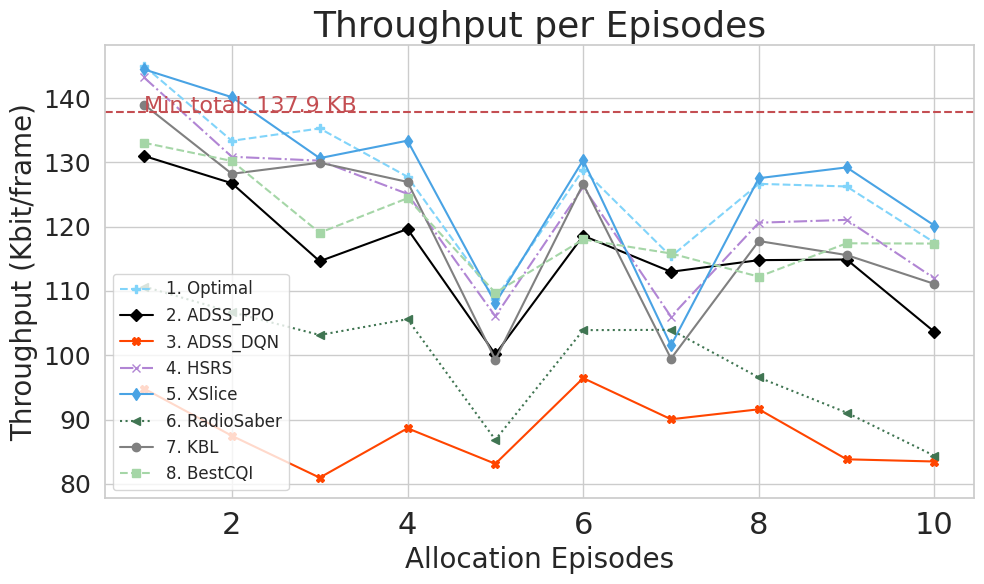

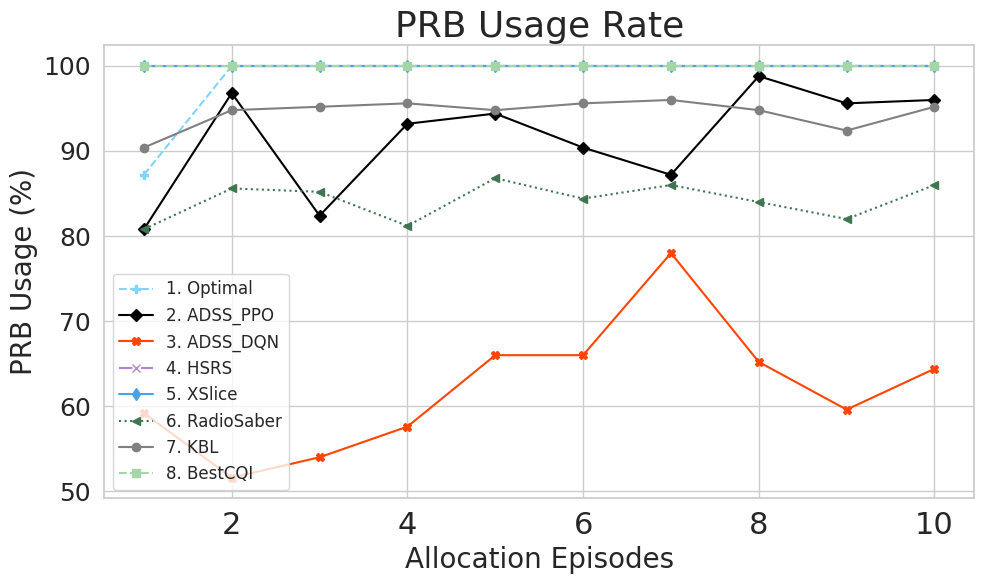

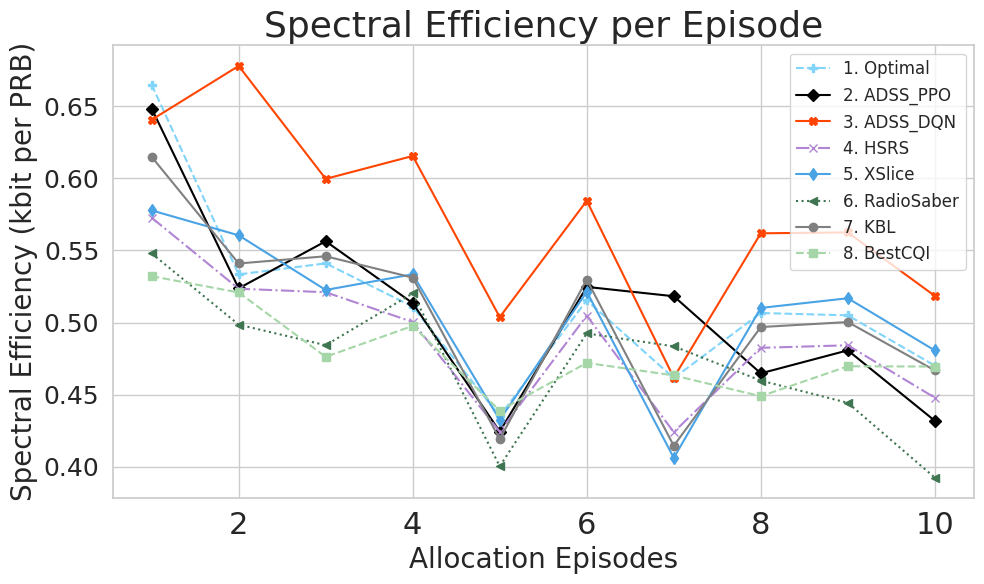

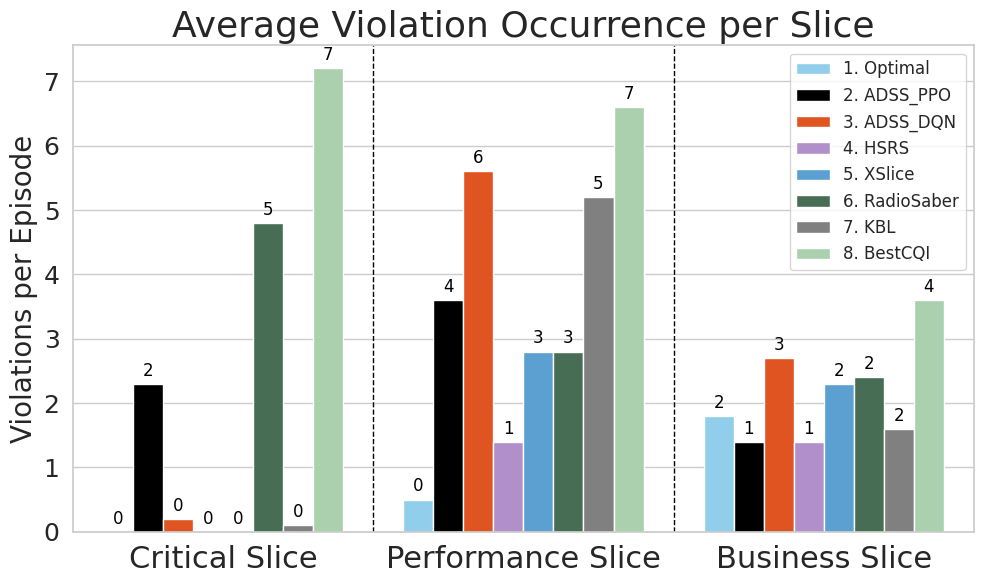

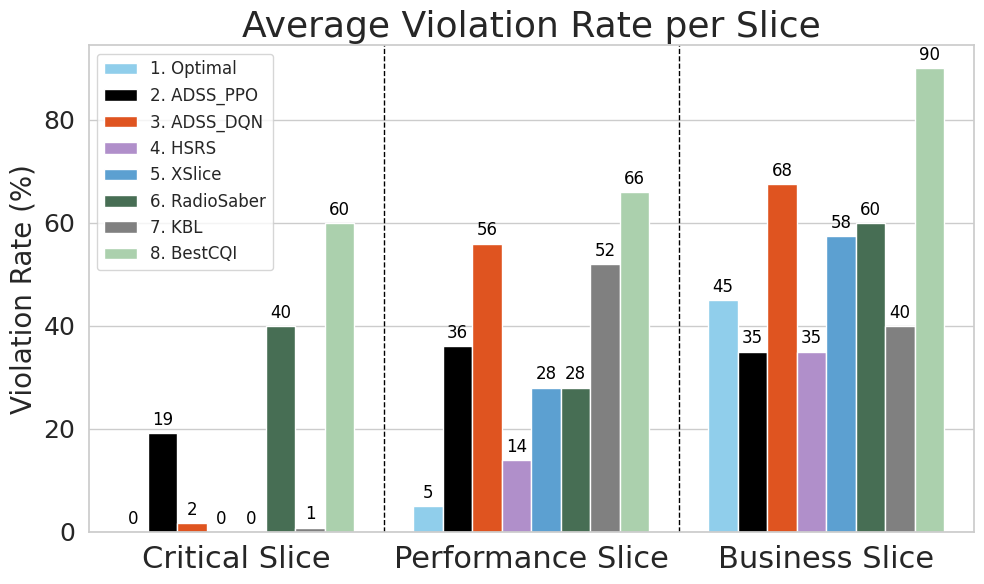

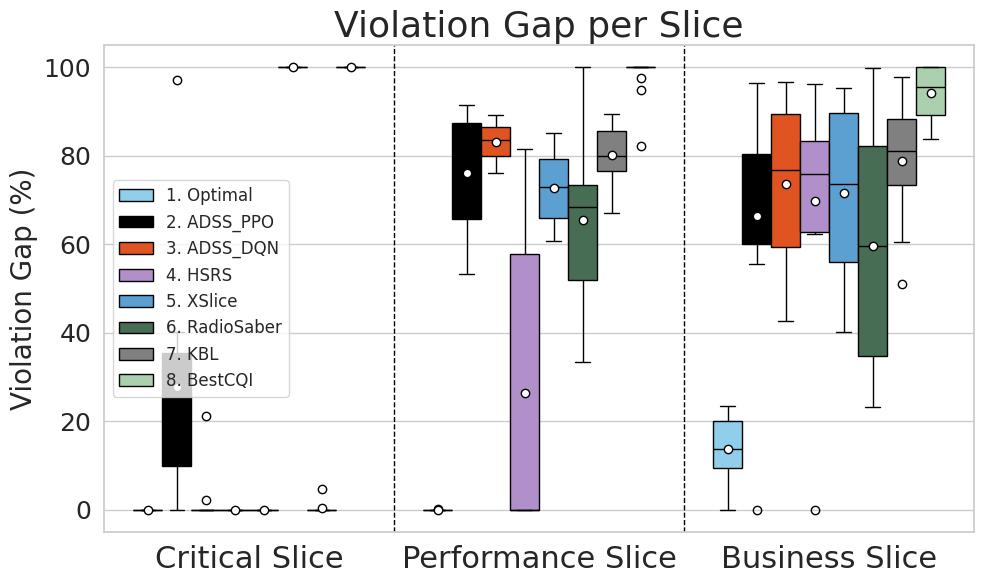

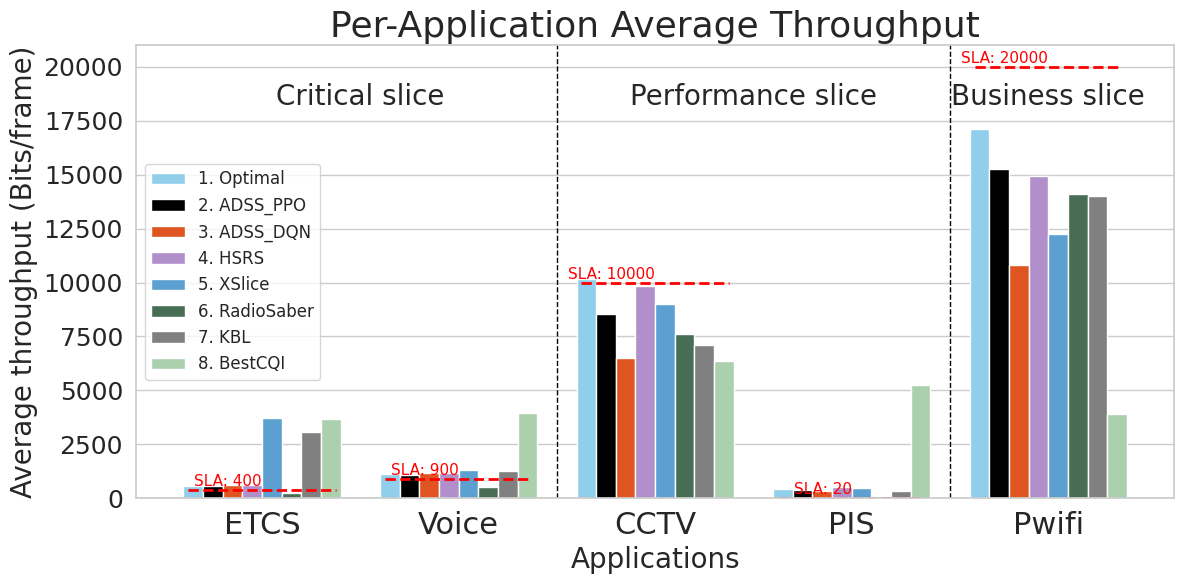

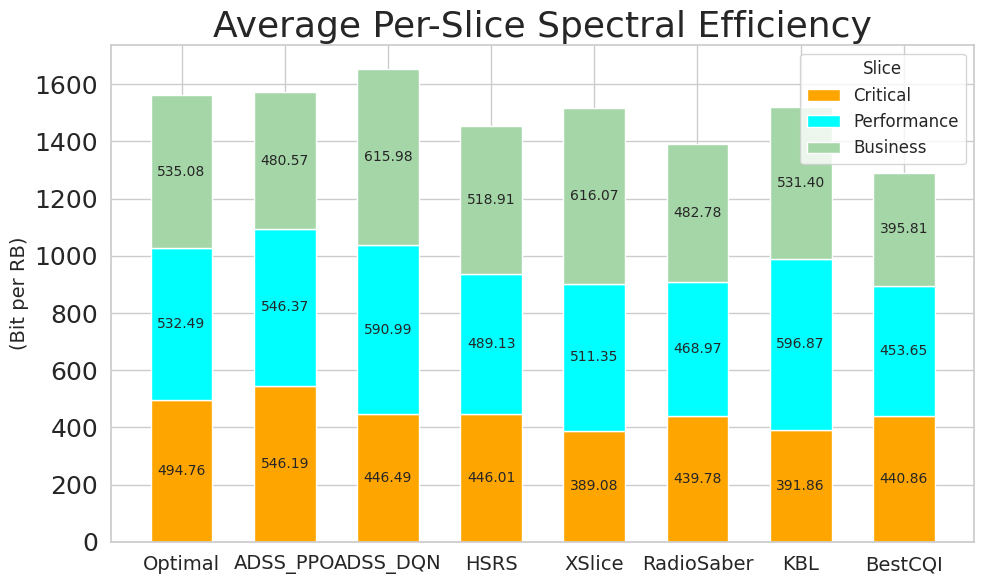

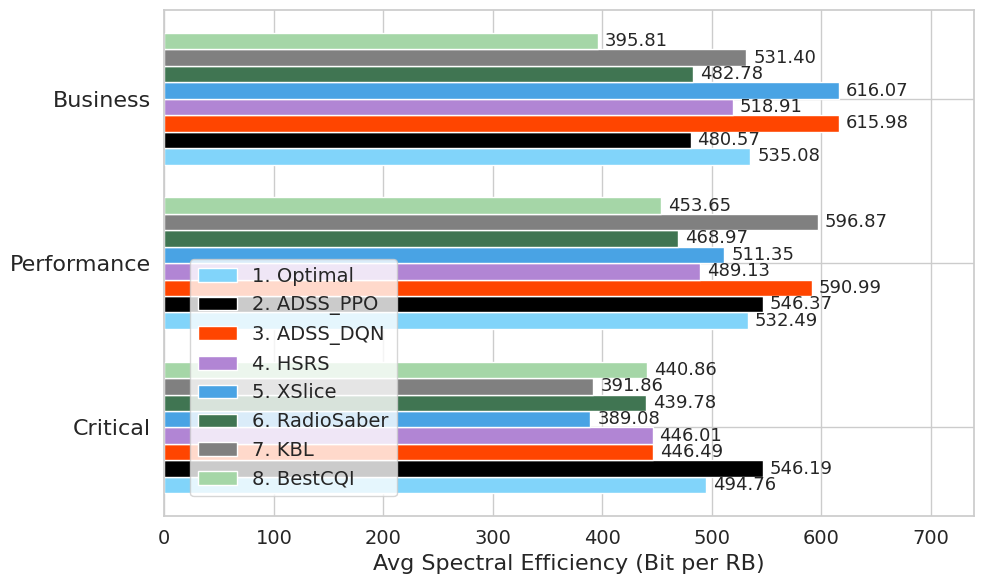

In [19]:
plot_all_results(results_df)

## time eval

In [4]:
results_df.to_csv("results_df.csv", index=False)
results_trimed = results_df[[
    'Optimal_ILP_Time_Taken',
    'ADSS_PPO_Time_Taken',
    'ADSS_DQN_Time_Taken',
    'HSRS_Time_Taken',
    'XSlice_Time_Taken',
    'RadioSaber_Time_Taken',
    'KBL_Time_Taken',
    'BestCQI_Time_Taken'
]]
meanvalues = results_df[[
    'Optimal_ILP_Time_Taken',
    'ADSS_PPO_Time_Taken',
    'ADSS_DQN_Time_Taken',
    'HSRS_Time_Taken',
    'XSlice_Time_Taken',
    'RadioSaber_Time_Taken',
    'KBL_Time_Taken',
    'BestCQI_Time_Taken'
]].mean()

print(meanvalues)


Optimal_ILP_Time_Taken    8.200864
ADSS_PPO_Time_Taken       0.139455
ADSS_DQN_Time_Taken       0.011000
HSRS_Time_Taken           0.050442
XSlice_Time_Taken         0.028042
RadioSaber_Time_Taken     0.015057
KBL_Time_Taken            0.039422
BestCQI_Time_Taken        0.034487
dtype: float64


## Visualizer

In [ ]:
from matplotlib.animation import FuncAnimation, PillowWriter

# 1) How many frames did we collect?
n_frames = len(frames)   # should equal num_simulations
fps      = 3             # adjust speed to taste
out_path = "allocation.gif"

# 2) Define the update function for FuncAnimation
def update(frame_idx):
    dfs = frames[frame_idx]
    for im, df in zip(images, dfs):
        grid_df = alloc_df_to_grid(df)
        arr     = (
            grid_df
            .replace(label_to_int)
            .fillna(3)
            .astype(int)
            .values.T
        )
        im.set_data(arr)
    fig.suptitle(f"Episode {frame_idx+1}/{n_frames}", fontsize=16)
    return images

# 3) Build and save the animation
anim = FuncAnimation(
    fig, update,
    frames=range(n_frames),
    blit=False,
    repeat=False
)
writer = PillowWriter(fps=fps)
anim.save(out_path, writer=writer)
print(f"✅ GIF saved to {out_path}")
